In [2]:
# ── 1. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('../Level1 Task2_EDA/Amazon Sale Report.csv', low_memory=False)

# Quick clean
df = df.dropna(subset=['Amount', 'Qty'])
df = df[df['Amount'] > 0]
df = df[df['Qty'] > 0]

print("Shape:", df.shape)
df[['Qty', 'Amount']].head()

Shape: (113701, 24)


,Qty,Amount
1,1,406.0
2,1,329.0
4,1,574.0
5,1,824.0
6,1,653.0


In [3]:
# ── 2. Select Features and Standardize ───────────────────────
features = df[['Qty', 'Amount']].copy()

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

print("Scaled data sample:")
print(scaled[:5])

Scaled data sample:
[[-0.05249347 -0.95409888]
 [-0.05249347 -1.23977407]
 [-0.05249347 -0.33080758]
 [-0.05249347  0.59670925]
 [-0.05249347 -0.03771226]]


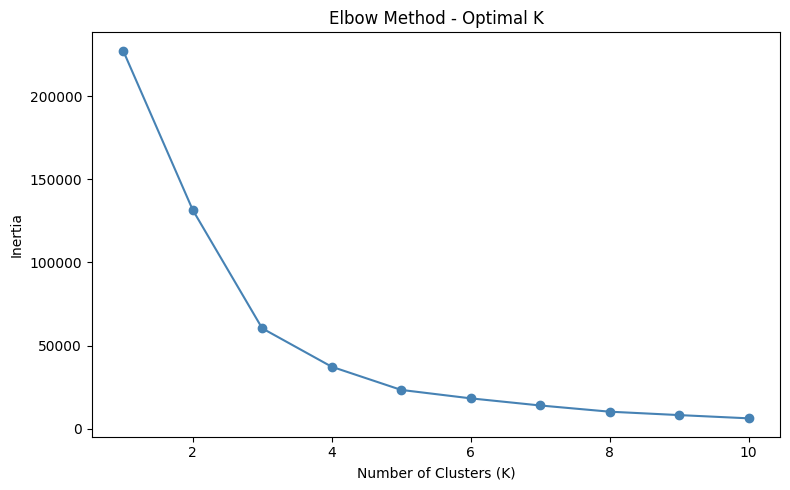

Elbow plot saved.


In [4]:
# ── 3. Elbow Method to Find Optimal K ────────────────────────
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal K')
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=300)
plt.show()
print("Elbow plot saved.")

In [5]:
# ── 4. Apply KMeans with Optimal K ───────────────────────────
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled)

print("Cluster distribution:")
print(df['Cluster'].value_counts())

Cluster distribution:
Cluster
0    70930
1    42392
2      379
Name: count, dtype: int64


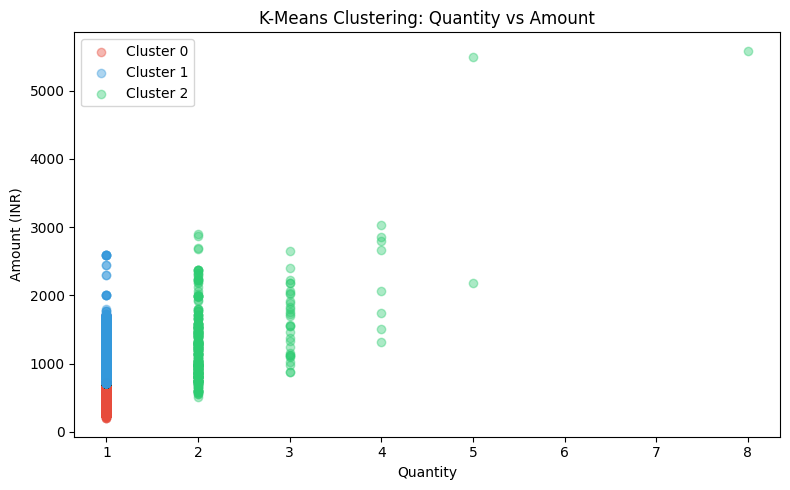

Cluster plot saved.


In [6]:
# ── 5. Visualize Clusters ─────────────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

for cluster in range(k):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Qty'],
        cluster_data['Amount'],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        alpha=0.4
    )

plt.xlabel('Quantity')
plt.ylabel('Amount (INR)')
plt.title('K-Means Clustering: Quantity vs Amount')
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=300)
plt.show()
print("Cluster plot saved.")

In [7]:
# ── 6. Cluster Summary ────────────────────────────────────────
summary = df.groupby('Cluster')[['Qty', 'Amount']].mean().round(2)
print("Cluster Means:")
print(summary)

Cluster Means:
          Qty   Amount
Cluster               
0        1.00   495.78
1        1.00   937.62
2        2.16  1291.70
